<a href="https://colab.research.google.com/github/NatGN/Practicas-de-seminario-de-mineria-de-datos/blob/main/RegresionManual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
train= pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

In [ ]:
train.info()

In [ ]:
train.columns

In [ ]:
train.head()

In [ ]:
#Ecuacion de la recta
# y= mx + b



In [ ]:
#GrLivArea
train['GrLivArea'].min()

334

In [ ]:
train['GrLivArea'].max()

5642

In [ ]:
#Correlacion
train['GrLivArea'].corr(train['SalePrice'])

np.float64(0.7086244776126523)

In [ ]:
train.plot.scatter(x='GrLivArea', y='SalePrice')

/tmp/ipykernel_148/4043725224.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


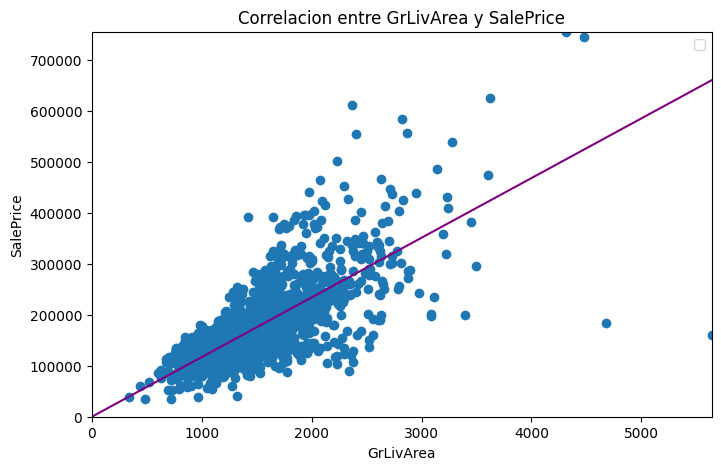

In [ ]:
#Definir parametros
m=117
b=0
#Graficar recta
x=np.linspace(0,train['GrLivArea'].max(),100)
y=m*x+b

#Graficar datos y recta
plt.figure(figsize=(8,5))
plt.scatter(train['GrLivArea'],train['SalePrice'])
plt.plot(x,y,color='purple')
plt.ylim(0,train['SalePrice'].max())
plt.xlim(0,train['GrLivArea'].max())
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.legend()
plt.title('Correlacion entre GrLivArea y SalePrice')
plt.show()

In [ ]:
#Si escogemos esos parametros
#Hacemos calculo de predicciones y guardamos como nueva columna

train['predd']=train['GrLivArea']*m+b


In [ ]:
#Calculamos el error cuadratico
train['diff'] = train['predd']-train['SalePrice']
train['cuad'] = train['diff']**2
train[['GrLivArea','SalePrice','predd','diff','cuad']].head(3)

,GrLivArea,SalePrice,predd,diff,cuad
0,1710,208500,213750,5250,27562500
1,1262,181500,157750,-23750,564062500
2,1786,223500,223250,-250,62500


In [ ]:
#Elegir parametros que miniminicen el error
#basado en m, b=0

m_grid=np.linspace(50,200,50) #Genera 50 puntos entre 50 y 200
grid_error=pd.DataFrame(m_grid,columns=['m'])
grid_error.head()

,m
0,50.000000
1,53.061224
2,56.122449
3,59.183673
4,62.244898


In [ ]:
#codigo que recibe un valor m
#Devuelve el MSE

def sum_error(m, train_df):
  b=0
  pred=train_df['GrLivArea']*m+b
  diff=pred-train_df['SalePrice']
  cuad=diff**2
  mse=cuad.mean()
  return mse

In [ ]:
#Aplicamos la funcion

grid_error['error']=grid_error['m'].apply(lambda x: sum_error(x,train))
grid_error.head()


,m,error
0,50.000000,1.509658e+10
1,53.061224,1.404857e+10
2,56.122449,1.304878e+10
3,59.183673,1.209720e+10
4,62.244898,1.119384e+10


In [ ]:
indice_minimo=grid_error['error'].idxmin()
min_row=grid_error.iloc[indice_minimo]
best_w=min_row['m']
best_error=min_row['error']

#Linea corregida
print(f"El mejor m encontrado: {best_w}")
print(f"El mejor error encontrado: {best_error: .2f}")


In [ ]:
#Grafica
plt.plot(grid_error['m'],grid_error['error'])
plt.xlabel('m')
plt.ylabel('error')
plt.title('Error vs m')
plt.show()

In [ ]:
# Predecir
m_optimo = 117
b_optimo = 0

def predict(gr_liv_area):
    return m_optimo * gr_liv_area + b_optimo

nueva_area = 20
precio_predicho = predict(nueva_area)

print(f"Prediccion para una casa de {nueva_area}: ${precio_predicho:.2f}")


Prediccion para una casa de 20: $2340.00
